# XBTorch::Example 03:Sample Device Non-Idealities

## Introduction

In this example, we will examine how different device non-idealities manifest in XBTorch device models. Specifically, we will utilize the analytical models and independently visualize device-to-device variability, cycle-to-cycle variability, and device non-linearity.

## Getting Started

Let's import necessary dependencies and write a helper function to assist in visualization.

In [1]:
# General Imports
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

In [2]:
# XBTorch imports
from xbtorch.devices.presets import AnalyticalReal
from xbtorch.devices.utils import sweep_conductance_full

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


Let's also fix the seed for reproducibility.

In [3]:
SEED = 512

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Let's write helper functions to help us visualize different device non-idealities.

In [4]:
def plot_individual_response(pulse_count, set_Gs, reset_Gs, colors, legend_text=None):
    # plot individual device responses directly
    plt.figure()

    for dev_num in range(len(set_Gs)):
        plt.plot(range(0, pulse_count), set_Gs[dev_num], c=colors[dev_num], label=f"{legend_text} {dev_num}")
        plt.plot(range(pulse_count + 1, pulse_count*2+1), reset_Gs[dev_num], c=colors[dev_num])

    if (legend_text): plt.legend()
            
    plt.xlabel('Pulse (#)')
    plt.ylabel('Conductance (S)')

def plot_average_response(pulse_count, set_Gs, reset_Gs, colors, legend_text=["SET", "RESET"]):
    # plot average responses
    plt.figure()

    # plot the average responses for SET and RESET
    plt.plot(range(0, pulse_count), np.average(set_Gs, axis=0), label='SET')
    plt.fill_between(range(0, pulse_count), np.average(set_Gs, axis=0) - np.std(set_Gs, axis=0), np.average(set_Gs, axis=0) + np.std(set_Gs, axis=0), alpha=0.2)
    
    plt.plot(range(pulse_count + 1, pulse_count*2+1), np.average(reset_Gs, axis=0), label='RESET')
    plt.fill_between(range(pulse_count + 1, pulse_count*2+1), np.average(reset_Gs, axis=0) - np.std(reset_Gs, axis=0), np.average(reset_Gs, axis=0) + np.std(reset_Gs, axis=0), alpha=0.2)

    if (legend_text): plt.legend()
            
    plt.xlabel('Pulse (#)')
    plt.ylabel('Conductance (S)')

Let's also instantiate color maps for nicer visualization later.

In [5]:
# Create a colormap from white to the base color
CMAP_BLUE = plt.get_cmap('Blues')
CMAP_RED = plt.get_cmap('Reds')
CMAP_GREEN = plt.get_cmap('Greens')

## Sampling Non-Idealities

We will use the same helper function from Example 01, `sweep_conductance_full()`, to sweep XBTorch devices.

Let's first see **device-to-device variability**. We will simulate and sweep a total of 3 analytical devices using the real preset. The analytical models have methods to set device-to-device and cycle-to-cycle variability directly, and we can utilize those to control the degree of each directly. 

In [6]:
# general parameters
NUM_DEVICES = 3
COLORS = [CMAP_BLUE(0.5), CMAP_RED(0.5), CMAP_GREEN(0.5)]

<Figure size 640x480 with 0 Axes>

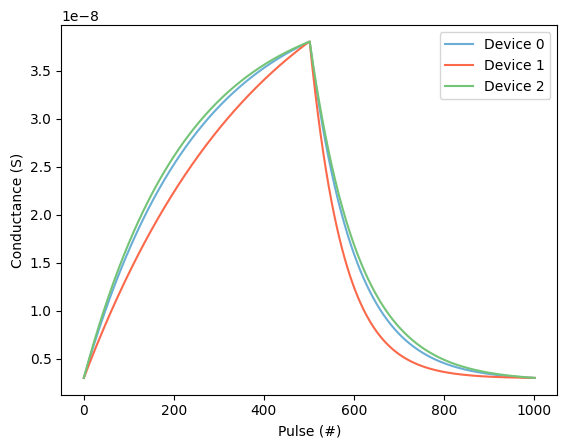

In [7]:
# instantiate an analytical real device model
device =  AnalyticalReal()

# only enable d2d variability
device.set_c2c_var(0.0)
device.set_d2d_var(1.0)

# get the total # of pulses required to set/reset the device
pulse_count = device.max_level + 1

plt.figure()
set_Gs, reset_Gs = np.zeros((NUM_DEVICES, device.max_level+1)), np.zeros((NUM_DEVICES, device.max_level+1))

# sweep conductance of each device
for dev_num in range(NUM_DEVICES):
    set_Gs[dev_num], reset_Gs[dev_num] = sweep_conductance_full(device, dev_num)
    device.reset_cached_params()

p1 = plot_individual_response(pulse_count, set_Gs, reset_Gs, colors=COLORS, legend_text="Device")

Similarly, we can see **cycle-to-cycle variability**. Instead of plotting individual cycles, let's visualize the average device response.

In [8]:
NUM_CYCLES = 10

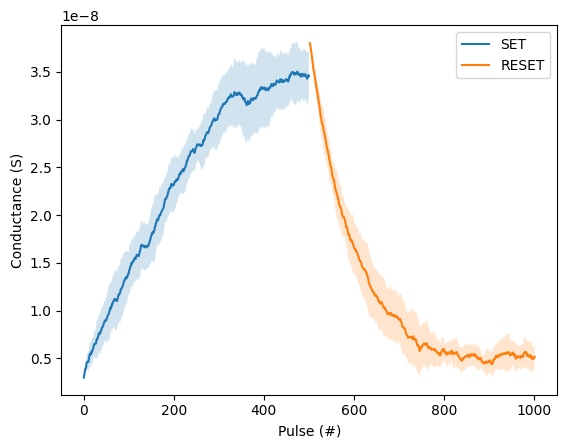

In [9]:
# cycle to cycle variability
device.set_c2c_var(0.01) # 1 % C2C variability
device.set_d2d_var(0.0)
set_Gs, reset_Gs = np.zeros((NUM_CYCLES, device.max_level+1)), np.zeros((NUM_CYCLES, device.max_level+1))

for cycle in range(NUM_CYCLES): 
    set_Gs[cycle], reset_Gs[cycle] = sweep_conductance_full(device)
    device.reset_cached_params() # not needed, but good practice to stay consistent

p2 = plot_average_response(pulse_count, set_Gs, reset_Gs, colors=COLORS, legend_text="Device")

Finally, let's visualize non-linearity. The non-linearity parameter of a device can be controlled similar to how we specified cycle-to-cycle and device-to-device variabilities above. The parameter has a similar meaning as the work on NeuroSim by the original authors [1].

In [10]:
NON_LINEARITIES = range(0, 6)
NUM_DEVICES = len(NON_LINEARITIES) # each non-linearity will correspond to a unique device
COLORS = CMAP_BLUE(np.linspace(0.2, 0.8, NUM_DEVICES))

<Figure size 640x480 with 0 Axes>

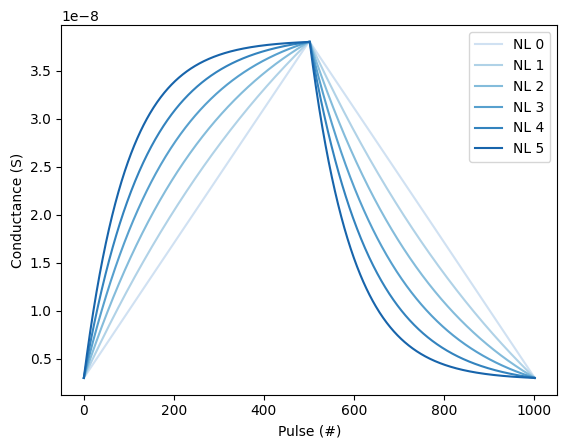

In [11]:
# disable c2c as well as d2d variability
device.set_c2c_var(0.0)
device.set_d2d_var(0.0)

plt.figure()
set_Gs, reset_Gs = np.zeros((NUM_DEVICES, device.max_level+1)), np.zeros((NUM_DEVICES, device.max_level+1))

# sweep conductance of each device
for idx in range(len(NON_LINEARITIES)):
    device.set_nonlinearity_set(NON_LINEARITIES[idx])
    device.set_nonlinearity_reset(-NON_LINEARITIES[idx])
    set_Gs[idx], reset_Gs[idx] = sweep_conductance_full(device)
    device.reset_cached_params()

p3 = plot_individual_response(pulse_count, set_Gs, reset_Gs, colors=COLORS, legend_text="NL")

## Conclusion
We now know how to sample various device non-idealities using the analytical device model. The tabular device model does not allow such on-the-fly adjustments since it is created one-time for a given device dataset. However, the tabular models do have an advantage over analytical models in terms of the overall computation speed. We will compare this in the next example notebook.

## References
1. Peng, X., Huang, S., Jiang, H., Lu, A., & Yu, S. (2020). DNN+NeuroSim V2.0: An end-to-end benchmarking framework for compute-in-memory accelerators for on-chip training. IEEE Transactions on Computer-Aided Design of Integrated Circuits and Systems, 40(11), 2306-2319.